In [61]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, model_selection

In [62]:
# Get dataset description
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
print(diabetes.DESCR) 

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [63]:
X, y = datasets.load_diabetes(return_X_y=True)
print("Type of X:", type(X))
print("Data type of elements:", X.dtype)
print(X.shape)
print(X[0])

Type of X: <class 'numpy.ndarray'>
Data type of elements: float64
(442, 10)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [64]:
# View feature names
print("Feature names:", diabetes.feature_names)
print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Number of samples: 442
Number of features: 10


In [65]:
# Create a DataFrame for better visualization
import pandas as pd

df = pd.DataFrame(X, columns=diabetes.feature_names)
df['target'] = y

print(df.head())
print("\nBasic statistics:")
print(df.describe())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Basic statistics:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.7619

In [66]:
# Select only the BMI feature (column index 2)
X = X[:, 3]

# Reshape from 1D (442,) to 2D (442, 1) for sklearn compatibility
X = X.reshape((-1, 1))

print("X.shape: ", X.shape)
print("X: ", X)

X.shape:  (442, 1)
X:  [[ 2.18723855e-02]
 [-2.63275281e-02]
 [-5.67042229e-03]
 [-3.66560811e-02]
 [ 2.18723855e-02]
 [-1.94418262e-02]
 [-1.59989752e-02]
 [ 6.66294482e-02]
 [-4.00989321e-02]
 [-3.32132301e-02]
 [ 8.10098161e-03]
 [-3.32132301e-02]
 [-9.11327327e-03]
 [ 8.10098161e-03]
 [-1.25561242e-02]
 [ 8.04008521e-02]
 [ 4.94151933e-02]
 [ 5.63008953e-02]
 [-3.66560811e-02]
 [-4.00989321e-02]
 [-4.35417830e-02]
 [ 1.21527966e-03]
 [-9.11327327e-03]
 [ 3.10647976e-02]
 [-2.28846772e-02]
 [-4.00989321e-02]
 [-2.63275281e-02]
 [-4.00989321e-02]
 [-7.45274418e-02]
 [ 6.31865972e-02]
 [-1.94418262e-02]
 [-8.14131438e-02]
 [ 2.87580875e-02]
 [-2.22757132e-03]
 [-5.73131869e-02]
 [-4.92913442e-02]
 [ 5.28580443e-02]
 [-5.73131869e-02]
 [ 9.76151070e-02]
 [-7.45274418e-02]
 [ 2.18723855e-02]
 [-1.08955952e-01]
 [-1.48628344e-02]
 [-7.10845908e-02]
 [ 8.10098161e-03]
 [ 3.22009384e-02]
 [-3.32132301e-02]
 [-5.73131869e-02]
 [ 1.15438326e-02]
 [-5.67042229e-03]
 [ 1.49866836e-02]
 [ 2.875

In [67]:
# Split the data into training and testing sets
# X: features (BMI values), y: target (disease progression)
# test_size=0.33 means 33% of data for testing, 67% for training
# This helps evaluate model performance on unseen data
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.33)

In [68]:
# Create a linear regression model object
# This model will learn the relationship between BMI and disease progression
model = linear_model.LinearRegression()

# Train the model using the training data
# fit() finds the best line (slope and intercept) that minimizes prediction errors
# X_train: BMI values for training
# y_train: actual disease progression values for training
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
# Make predictions on the test set
# Uses the trained model to predict disease progression for test BMI values
# This tests how well the model generalizes to new, unseen data
y_pred = model.predict(X_test)

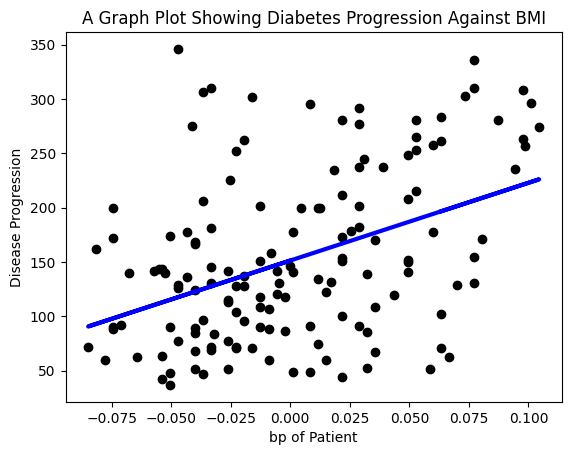

In [70]:
# Create a scatter plot of actual test data points
# X_test: BMI values from test set
# y_test: actual disease progression from test set
# color='black': plot points in black
plt.scatter(X_test, y_test, color='black')

# Plot the regression line (predictions)
# X_test: BMI values from test set
# y_pred: predicted disease progression values
# color='blue': plot line in blue
# linewidth=3: make the line thicker for visibility
plt.plot(X_test, y_pred, color='blue', linewidth=3)

# Label the x-axis (horizontal axis)
plt.xlabel('bp of Patient')

# Label the y-axis (vertical axis)
plt.ylabel('Disease Progression')

# Add a title to the plot
plt.title('A Graph Plot Showing Diabetes Progression Against BMI')

# Display the plot
plt.show()

X[:, 3]
 ↑   ↑
 |   └─ Column selector: "Give me column 3 (blood pressure)"
 └───── Row selector: ":" means "all rows" (all 442 patients)

Result: A vertical slice through the matrix
        Extract one feature for all patients

Key Insight: The colon : means "everything" in that dimension, so X[:, 3] means "all rows, but only column 3".


# Load and visualize the structure
X, y = datasets.load_diabetes(return_X_y=True)

# X is a 2D array (matrix) with shape (442, 10)
# Think of it as a spreadsheet:

    Column:  0      1      2      3      4      5      6      7      8      9
           [age]  [sex]  [bmi]  [bp]   [s1]   [s2]   [s3]   [s4]   [s5]   [s6]
Row 0    [ 0.03,  0.05, -0.04,  0.02,  0.01, -0.02, -0.03,  0.00,  0.01, -0.01 ]
Row 1    [-0.01, -0.04,  0.05,  0.03, -0.02,  0.01,  0.00, -0.01,  0.03,  0.02 ]
Row 2    [ 0.08,  0.05,  0.00, -0.03,  0.04, -0.01,  0.02, -0.02,  0.01,  0.00 ]
...
Row 441  [ 0.02,  0.04, -0.01,  0.01,  0.03, -0.02,  0.00,  0.01, -0.01,  0.02 ]
         ↑                      ↑
         |                      |
     X[:, 0]                X[:, 3]
    (all rows,             (all rows,
   column 0: age)      column 3: blood pressure)


# Check the type of X
print(type(X))
# Output: <class 'numpy.ndarray'>

# NumPy arrays have special attributes
print("Type:", type(X))
print("Shape:", X.shape)
print("Data type:", X.dtype)
print("Number of dimensions:", X.ndim)